[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1CSuVstmF3QCj9XvOZtuC0KbgAdH_RKJs#scrollTo=0xiK5vO32lus)

# Exploratory Data Analysis
This is a notebook dedicated to exploring the data and understanding how the variables behave.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings for academic reports and presentations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.figsize': (14, 10),
    'axes.labelsize': 12,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

In [ ]:
# Automatically read the database provided for the problem
df = pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv")


In [ ]:
# Adjusting variable names (Friendly names)
friendly_names = {
    'kw': 'Energy Production (kW)', # Our Target Variable
    'capacity_clipped': 'Installed Capacity',
    'S_d': 'Direct Solar Radiation',
    'airmass': 'Air Mass',
    'altitude': 'Solar Altitude',
    'azimuth': 'Solar Azimuth',
    'irradiation': 'Irradiance',
    'fold_cos': 'Angular Factor (Fold)',
    'panel_cos': 'Angular Factor (Panel)',
    'rad_lw_mean': 'Longwave Radiation',
    'precip_total_mean': 'Precipitation (Rain)',
    'cloud_total_mean': 'Clouds (Total)',
    'temp_total_mean': 'Temperature',
    'cloud_high_mean': 'Clouds (High)',
    'rad_global_mean': 'Global Radiation',
    'cloud_low_mean': 'Clouds (Low)',
    'radNetS_lw_mean': 'Net Longwave Radiation',
    'cloud_mid_mean': 'Clouds (Mid)',
    'radNetS_sw_mean': 'Net Shortwave Radiation'
}

# Renaming dataframe columns for better readability
df = df.rename(columns=friendly_names)


[1] Columns with Null Values (NaN):
                         Total Nulls  Percentage (%)
Precipitation (Rain)            5517       23.511613
Clouds (Total)                  1116        4.756020
Temperature                     1116        4.756020
Clouds (High)                   1116        4.756020
Global Radiation                1116        4.756020
Clouds (Low)                    1116        4.756020
Net Longwave Radiation          1116        4.756020
Longwave Radiation              1116        4.756020
Clouds (Mid)                    1116        4.756020
Net Shortwave Radiation         1116        4.756020

Collection Frequency Detection (Temporal Discrepancies):
  - Interval of 0 days 00:15:00: 16394 occurrences
  - Interval of 0 days 00:30:00: 4926 occurrences
  - Interval of 0 days 00:45:00: 1496 occurrences
  - Interval of 0 days 01:00:00: 430 occurrences
  - Interval of 0 days 01:15:00: 134 occurrences
  - Interval of 0 days 01:30:00: 40 occurrences
  - Interval of 0 days 06

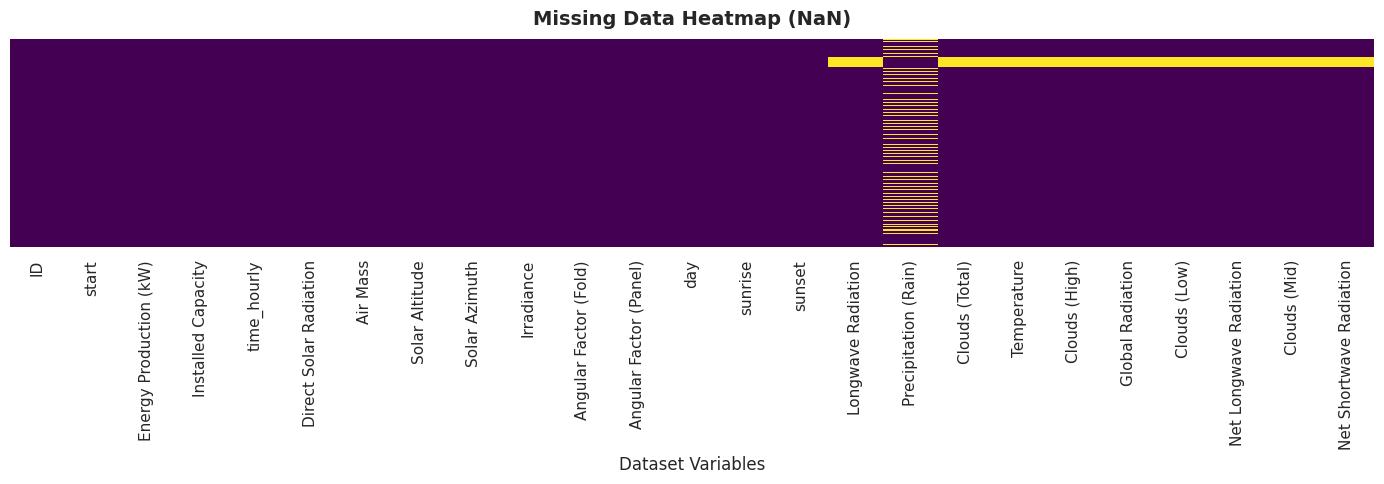

In [ ]:
# Performing data cleaning - DIAGNOSIS OF MISSING DATA AND FREQUENCY DISCREPANCIES

# 1. IDENTIFICATION OF GAPS (NULL VALUES)
null_values = df.isnull().sum()  # Counts nulls per column
null_percentage = (null_values / len(df)) * 100  # Calculates the percentage of nulls

# Consolidates nulls into a DataFrame for organized visualization
null_diagnosis = pd.DataFrame({'Total Nulls': null_values, 'Percentage (%)': null_percentage})
null_diagnosis = null_diagnosis.sort_values(by='Total Nulls', ascending=False)

# Filters and displays only the columns that actually have some gaps
columns_with_nulls = null_diagnosis[null_diagnosis['Total Nulls'] > 0]
print("\n[1] Columns with Null Values (NaN):")
print(columns_with_nulls if not columns_with_nulls.empty else "✓ No null data found.")

# 2. IDENTIFICATION OF TIME INTERVAL DISCREPANCIES (15 min vs 30 min)
time_column = 'start'  # Defines the technical name of the original time column

if time_column in df.columns:
    # Ensures conversion of text column to datetime format
    df[time_column] = pd.to_datetime(df[time_column])

    # Sorts chronologically to ensure row-to-row calculations make sense
    df = df.sort_values(by=time_column).reset_index(drop=True)

    # Calculates the time difference between each row and the immediately preceding row
    intervals = df[time_column].diff()

    # Counts the frequency of each time interval in the dataset
    interval_frequency = intervals.value_counts()

    print("\nCollection Frequency Detection (Temporal Discrepancies):")
    for time_diff, count in interval_frequency.items():
        # Displays the found interval and how many times it occurred cleanly
        print(f"  - Interval of {time_diff}: {count} occurrences")

    # Identifies if there are multiple mixed time patterns
    if len(interval_frequency) > 1:
        print("Dataset with mixed frequencies!")
else:
    print(f"Error: The column '{time_column}' was not found for temporal analysis.")

# 3. PLOTTING THE VISUAL NULL MAP
plt.figure(figsize=(14, 5))  # Sets the chart size
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')  # Plots the binary null matrix
plt.title('Missing Data Heatmap (NaN)', fontsize=14, fontweight='bold', pad=10)  # Chart title
plt.xlabel('Dataset Variables')  # X-axis label
plt.tight_layout()  # Adjusts chart spacing automatically
plt.show()  # Renders the chart on the screen

In [ ]:
# MULTIVARIATE FREQUENCY IMPACT ANALYSIS

# Calculates the time difference and temporarily saves it as a string in the table
df['intervalo_tempo'] = df['start'].diff().fillna(pd.Timedelta(seconds=0)).astype(str)

# Defines an array with critical variables of different physical natures
# Updated to match the new English column names
variaveis_criticas = ['Precipitation (Rain)', 'Temperature', 'Irradiance', 'Energy Production (kW)']

# Filters the array keeping only the columns that actually exist in this dataset
features_existentes = [col for col in variaveis_criticas if col in df.columns]

# Checks if there are valid columns in the set to perform the grouping
if features_existentes:
    # Groups the data by interval and calculates the mean and standard deviation of each
    analise_impacto = df.groupby('intervalo_tempo')[features_existentes].agg(['mean', 'std'])
    # Shows the generated comparative statistical summary
    print("State and Accumulation Statistics by Collected Interval:")
    # Prints the matrix containing the multivariate statistical behavior
    print(analise_impacto)

# Removes the auxiliary column from the DataFrame to keep the table clean
df = df.drop(columns=['intervalo_tempo'])

State and Accumulation Statistics by Collected Interval:
                Precipitation (Rain)           Temperature            \
                                mean       std        mean       std   
intervalo_tempo                                                        
0 days 00:00:00                  NaN       NaN    2.016479       NaN   
0 days 00:15:00             0.007581  0.025777   13.019995  8.667904   
0 days 00:30:00             0.007363  0.027779   13.087951  8.597729   
0 days 00:45:00             0.007482  0.029779   12.968321  8.566052   
0 days 01:00:00             0.005651  0.009998   13.499647  8.369126   
0 days 01:15:00             0.007059  0.014936   13.033134  8.778388   
0 days 01:30:00             0.015022  0.039505   11.591436  5.914249   
0 days 01:45:00             0.008000  0.008000   15.259593  6.658000   
0 days 02:00:00             0.007200  0.007155   10.595390  5.332912   
0 days 05:15:00             0.004000       NaN         NaN       NaN   
0 days 

In [ ]:
# Searches for state variables that still contain null data post-resampling
colunas_para_interpolacao = [col for col in df.columns if col != 'Precipitation (Rain)' and df[col].isnull().sum() > 0]

# Checks if there are columns eligible for state filling
if colunas_para_interpolacao:
    # Displays which specific state variables will undergo correction
    print(f"Applying linear interpolation to state variables: {colunas_para_interpolacao}")
    # Linearly interpolates the gaps limiting the filling in both directions of the series
    df[colunas_para_interpolacao] = df[colunas_para_interpolacao].interpolate(method='linear', limit_direction='both')

# Checks if precipitation still needs imputation for the block of nulls
if 'Precipitation (Rain)' in df.columns and df['Precipitation (Rain)'].isnull().sum() > 0:
    # Prints warning detailing the seasonal climatological modeling process of rain
    print("Reconstructing empty Precipitation via Monthly-Hourly seasonality profile...")

    # Extracts the month corresponding to each date index in the history
    df['aux_mes'] = df['start'].dt.month
    # Extracts the hour corresponding to each point in time
    df['aux_hora'] = df['start'].dt.hour

    # Groups by the month-hour binomial and projects the respective historical average on each row
    perfil_chuva = df.groupby(['aux_mes', 'aux_hora'])['Precipitation (Rain)'].transform('mean')

    # Fills the accumulated nulls using the average profile of the respective month and hour
    df['Precipitation (Rain)'] = df['Precipitation (Rain)'].fillna(perfil_chuva)

    # Applies replacement by absolute zero in case any inconsistency remains at the beginning of the dataset
    df['Precipitation (Rain)'] = df['Precipitation (Rain)'].fillna(0.0)

    # Removes the temporary month column used in the auxiliary mapping
    df = df.drop(columns=['aux_mes'])
    # Removes the temporary hour column used in the auxiliary mapping
    df = df.drop(columns=['aux_hora'])

# Removes the date from the index putting it back as a conventional column named 'start'
df = df.reset_index(drop=True)

# Prints confirmation message of final consistency of the treated data
print(f"\n✓ Temporal physical alignment completed for full 1 Hour.")
# Displays mathematical verification proving no nulls remained in the DataFrame
print(f"✓ Remaining null records in the entire DataFrame: {df.isnull().sum().sum()}")
# Presents the new symmetrical dimension of the data to confirm the final scale
print(f"✓ Final dimension of the sanitized dataset: {df.shape[0]} rows.")

Applying linear interpolation to state variables: ['Longwave Radiation', 'Clouds (Total)', 'Temperature', 'Clouds (High)', 'Global Radiation', 'Clouds (Low)', 'Net Longwave Radiation', 'Clouds (Mid)', 'Net Shortwave Radiation']
Reconstructing empty Precipitation via Monthly-Hourly seasonality profile...

✓ Temporal physical alignment completed for full 1 Hour.
✓ Remaining null records in the entire DataFrame: 0
✓ Final dimension of the sanitized dataset: 23465 rows.


In [ ]:
# DISCREPANCY TREATMENT AND NULL IMPUTATION

# Sets the 'start' column as the chronological reference index of the DataFrame
df = df.set_index('start')

# Filters numerical columns (except rain) to apply the mean rule
regras_media = {col: 'mean' for col in df.columns if col != 'Precipitation (Rain)' and pd.api.types.is_numeric_dtype(df[col])}

# Explicitly assigns the sum rule for total accumulated precipitation
regras_soma = {'Precipitation (Rain)': 'sum'} if 'Precipitation (Rain)' in df.columns else {}

# Joins the rules into a single map of aggregation instructions
regras_agregacao = {**regras_media, **regras_soma}

# Prints warning informing the standardization of frequencies to full 1h intervals
print("Resampling and standardizing the history to the full 1 Hour format...")
# Executes pandas resampling aggregating according to the designed physical directives
df = df.resample('h').agg(regras_agregacao)

# Searches for state variables that still contain null data post-resampling
colunas_para_interpolacao = [col for col in df.columns if col != 'Precipitation (Rain)' and df[col].isnull().sum() > 0]

# Checks if there are columns eligible for state filling
if colunas_para_interpolacao:
    # Displays which specific state variables will undergo correction
    print(f"Applying linear interpolation to state variables: {colunas_para_interpolacao}")
    # Linearly interpolates the gaps limiting the filling in both directions of the series
    df[colunas_para_interpolacao] = df[colunas_para_interpolacao].interpolate(method='linear', limit_direction='both')

# Checks if precipitation still needs imputation for the block of nulls
if 'Precipitation (Rain)' in df.columns and df['Precipitation (Rain)'].isnull().sum() > 0:
    # Prints warning detailing the seasonal climatological modeling process of rain
    print("Reconstructing empty Precipitation via Monthly-Hourly seasonality profile...")

    # Extracts the month corresponding to each date index in the history
    df['aux_mes'] = df.index.month
    # Extracts the hour corresponding to each point in time
    df['aux_hora'] = df.index.hour

    # Groups by the month-hour binomial and projects the respective historical average on each row
    perfil_chuva = df.groupby(['aux_mes', 'aux_hora'])['Precipitation (Rain)'].transform('mean')

    # Fills the accumulated nulls using the average profile of the respective month and hour
    df['Precipitation (Rain)'] = df['Precipitation (Rain)'].fillna(perfil_chuva)

    # Applies replacement by absolute zero in case any inconsistency remains at the beginning of the dataset
    df['Precipitation (Rain)'] = df['Precipitation (Rain)'].fillna(0.0)

    # Removes the temporary month column used in the auxiliary mapping
    df = df.drop(columns=['aux_mes'])
    # Removes the temporary hour column used in the auxiliary mapping
    df = df.drop(columns=['aux_hora'])

# Removes the date from the index putting it back as a conventional column named 'start'
df = df.reset_index()

# Prints confirmation message of final consistency of the treated data
print(f"\n✓ Temporal physical alignment completed for full 1 Hour.")
# Displays mathematical verification proving no nulls remained in the DataFrame
print(f"✓ Remaining null records in the entire DataFrame: {df.isnull().sum().sum()}")
# Presents the new symmetrical dimension of the data to confirm the final scale
print(f"✓ Final dimension of the sanitized dataset: {df.shape[0]} rows.")

Resampling and standardizing the history to the full 1 Hour format...
Applying linear interpolation to state variables: ['ID', 'Energy Production (kW)', 'Installed Capacity', 'Direct Solar Radiation', 'Air Mass', 'Solar Altitude', 'Solar Azimuth', 'Irradiance', 'Angular Factor (Fold)', 'Angular Factor (Panel)', 'Longwave Radiation', 'Clouds (Total)', 'Temperature', 'Clouds (High)', 'Global Radiation', 'Clouds (Low)', 'Net Longwave Radiation', 'Clouds (Mid)', 'Net Shortwave Radiation']

✓ Temporal physical alignment completed for full 1 Hour.
✓ Remaining null records in the entire DataFrame: 0
✓ Final dimension of the sanitized dataset: 8735 rows.


Establish correlations between the variables, aiming to analyze kW versus meteorological and solar variables.

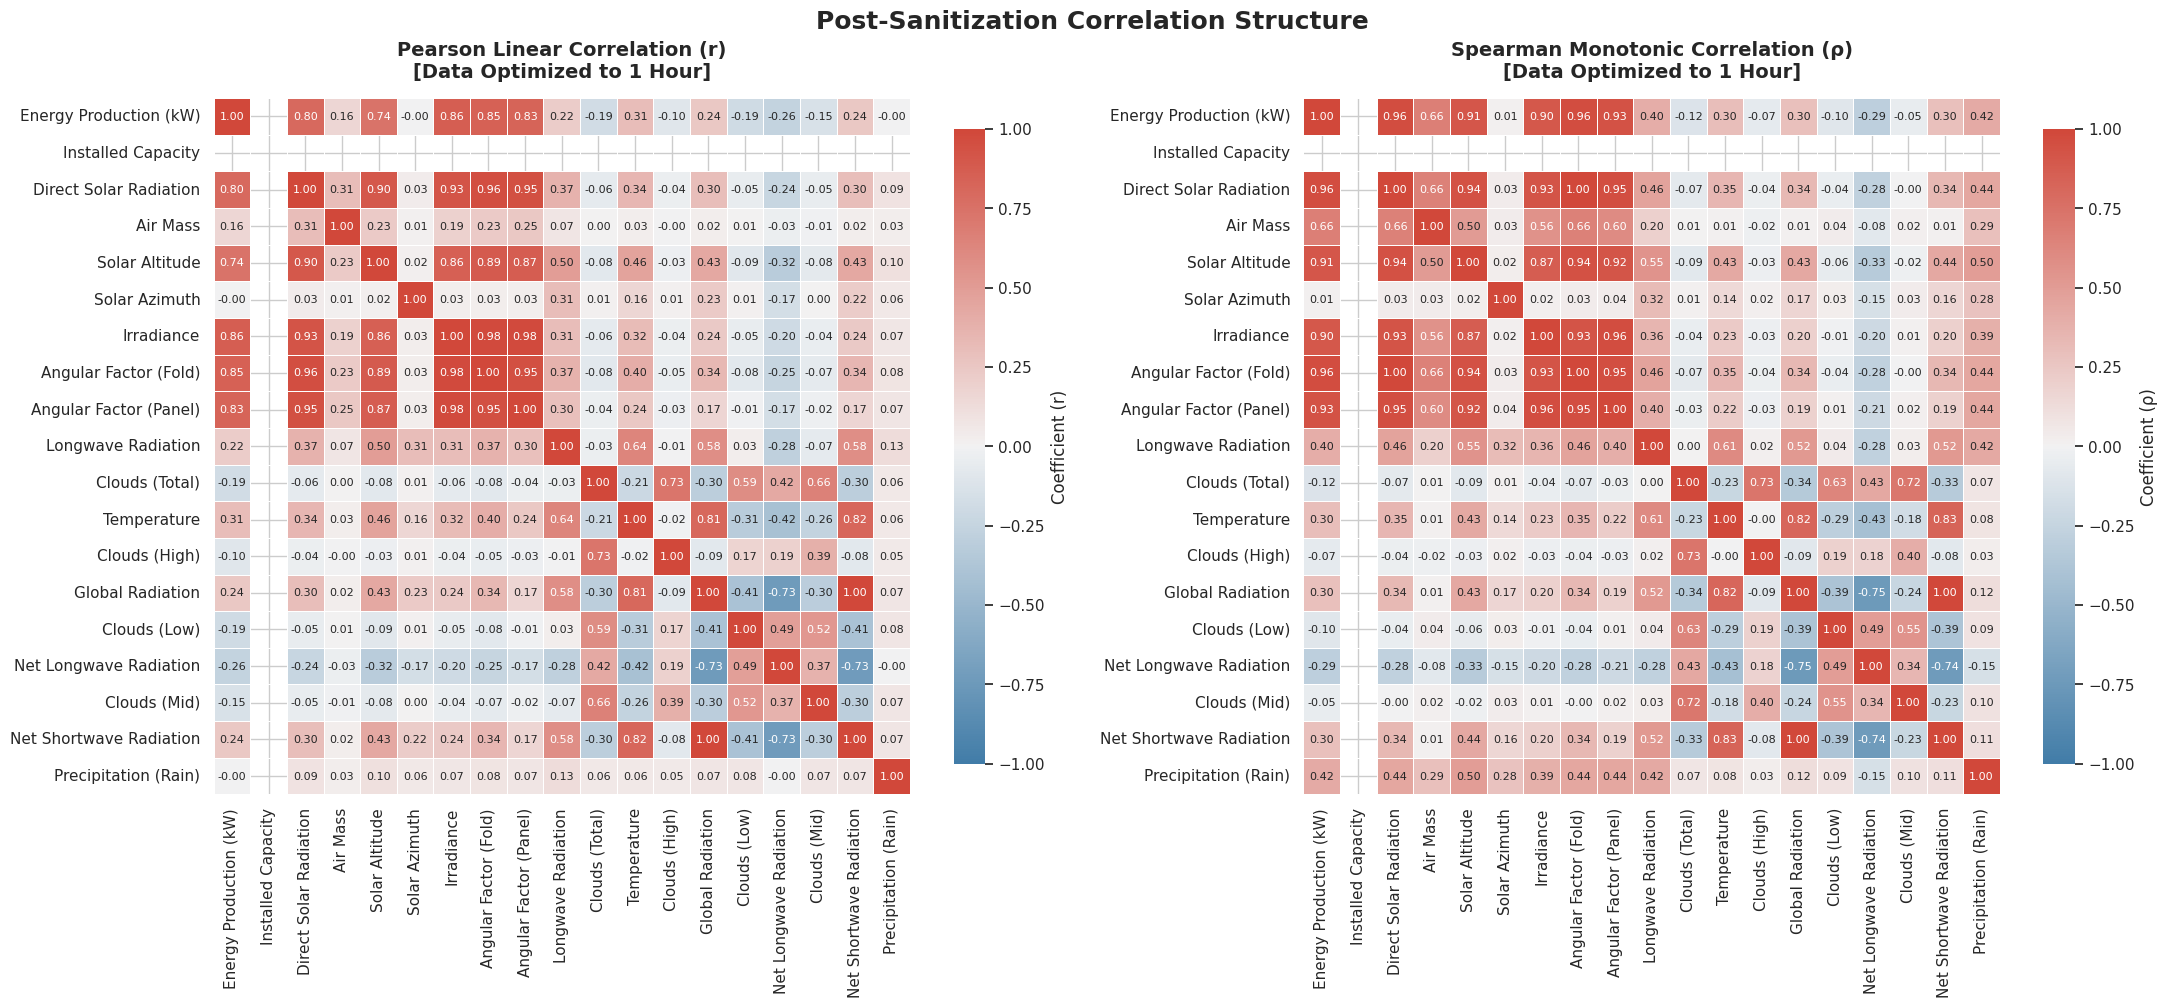

In [ ]:
# CALCULATION AND VISUALIZATION OF CORRELATION MATRICES (CLEAN DATA)

# 1. SELECTION OF NUMERICAL VARIABLES
# Filters the DataFrame to keep only mathematical columns (ignores dates)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Excludes identification columns that have no statistical value
columns_to_exclude = ['ID', 'id']
analysis_columns = [col for col in numeric_columns if col not in columns_to_exclude]

# 2. CALCULATION OF COEFFICIENTS
# Pearson: Measures the strength of the strictly linear relationship
corr_pearson = df[analysis_columns].corr(method='pearson')
# Spearman: Measures the strength of the relationship in curves (non-linear / monotonic)
corr_spearman = df[analysis_columns].corr(method='spearman')

# 3. PLOTTING THE HEATMAPS
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
diverging_cmap = sns.diverging_palette(240, 15, as_cmap=True)

# Heatmap 1: Pearson
sns.heatmap(
    corr_pearson, annot=True, cmap=diverging_cmap, fmt=".2f",
    vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Coefficient (r)"}, ax=axes[0],
    annot_kws={"size": 8} # Reduces the font size of numbers inside the squares
)
axes[0].set_title('Pearson Linear Correlation (r)\n[Data Optimized to 1 Hour]', pad=15, fontweight='bold', fontsize=14)

# Heatmap 2: Spearman
sns.heatmap(
    corr_spearman, annot=True, cmap=diverging_cmap, fmt=".2f",
    vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Coefficient (ρ)"}, ax=axes[1],
    annot_kws={"size": 8}
)
axes[1].set_title('Spearman Monotonic Correlation (ρ)\n[Data Optimized to 1 Hour]', pad=15, fontweight='bold', fontsize=14)
plt.suptitle('Post-Sanitization Correlation Structure', y=0.98, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

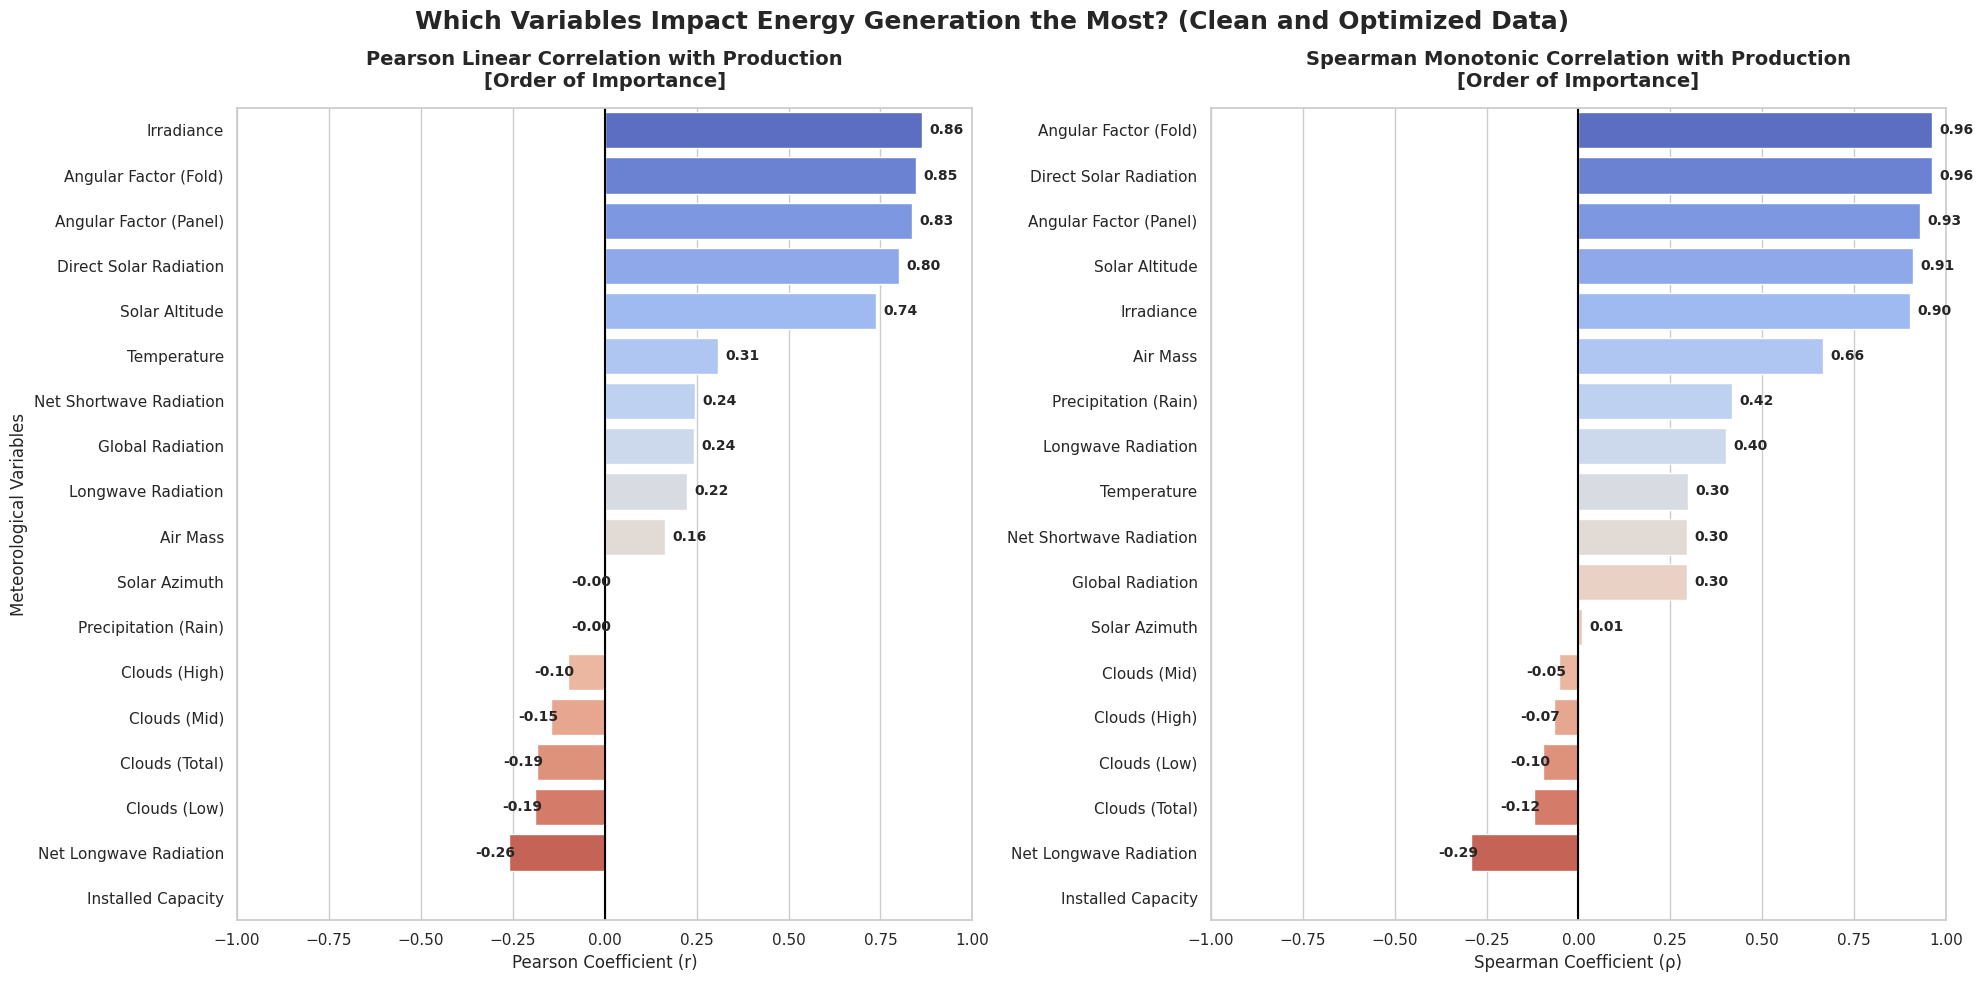

In [ ]:
# DIRECT IMPACT ON THE TARGET VARIABLE - energy production (ORDER OF IMPORTANCE)

# 1. SELECTION AND CALCULATION
# Filters only numerical columns, excluding IDs
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
analysis_columns = [col for col in numeric_columns if col not in ['ID', 'id']]

corr_pearson = df[analysis_columns].corr(method='pearson')
corr_spearman = df[analysis_columns].corr(method='spearman')

# 2. ISOLATING THE TARGET VARIABLE
target_variable = 'Energy Production (kW)'

if target_variable in corr_pearson.columns:
    # Extracts only the target column, removes the 1.0 correlation (it with itself) and sorts descending
    pearson_sorted = corr_pearson[target_variable].drop(target_variable).sort_values(ascending=False)
    spearman_sorted = corr_spearman[target_variable].drop(target_variable).sort_values(ascending=False)

    # 3. FIGURE PREPARATION
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # 4. CHART 1: PEARSON (LINEAR RELATIONSHIP)
    sns.barplot(
        x=pearson_sorted.values,
        y=pearson_sorted.index,
        ax=axes[0],
        palette="coolwarm", # Blue for negative, Red for positive
        hue=pearson_sorted.index,
        legend=False
    )
    axes[0].axvline(0, color='black', linestyle='-', linewidth=1.5) # Central zero line
    axes[0].set_title('Pearson Linear Correlation with Production\n[Order of Importance]', pad=15, fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Pearson Coefficient (r)', fontsize=12)
    axes[0].set_ylabel('Meteorological Variables', fontsize=12)
    axes[0].set_xlim(-1, 1) # Sets the limit from -1 to 1 to maintain mathematical proportion

    # Adds exact values next to each bar
    for i, v in enumerate(pearson_sorted.values):
        axes[0].text(v + (0.02 if v >= 0 else -0.09), i, f"{v:.2f}", va='center', fontweight='bold', fontsize=10)

    # 5. CHART 2: SPEARMAN (NON-LINEAR/MONOTONIC RELATIONSHIP)
    sns.barplot(
        x=spearman_sorted.values,
        y=spearman_sorted.index,
        ax=axes[1],
        palette="coolwarm",
        hue=spearman_sorted.index,
        legend=False
    )
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5)
    axes[1].set_title('Spearman Monotonic Correlation with Production\n[Order of Importance]', pad=15, fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Spearman Coefficient (ρ)', fontsize=12)
    axes[1].set_ylabel('') # Removes repeated Y labels
    axes[1].set_xlim(-1, 1)

    # Adds exact values next to each bar
    for i, v in enumerate(spearman_sorted.values):
        axes[1].text(v + (0.02 if v >= 0 else -0.09), i, f"{v:.2f}", va='center', fontweight='bold', fontsize=10)

    # General Title
    plt.suptitle('Which Variables Impact Energy Generation the Most? (Clean and Optimized Data)', y=0.98, fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

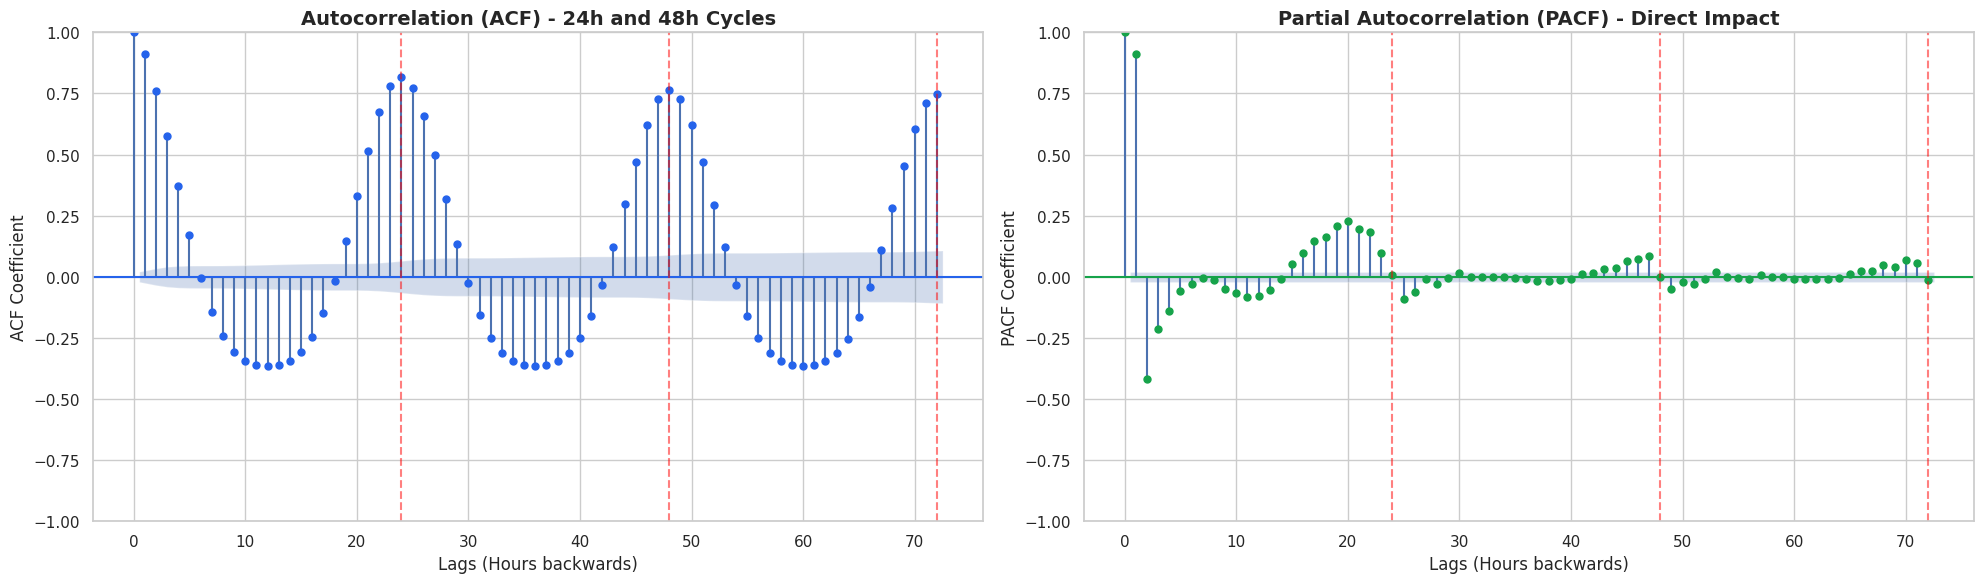

⚠ Multicollinearity detected among ['Direct Solar Radiation', 'Irradiance', 'Global Radiation']. Keeping only the strongest.

✓ Feature Selection Completed! From 19 original variables, we kept the Top 8:
  [+] Solar Altitude (Impact: 0.74)
  [+] Angular Factor (Fold) (Impact: 0.85)
  [+] Angular Factor (Panel) (Impact: 0.83)
  [+] Longwave Radiation (Impact: 0.22)
  [+] Temperature (Impact: 0.31)
  [-] Net Longwave Radiation (Impact: -0.26)
  [+] Net Shortwave Radiation (Impact: 0.24)
  [+] Irradiance (Impact: 0.86)


In [ ]:
# Temporal analysis: Seasonality and autocorrelation (ACF/PACF)

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

variavel_alvo = 'Energy Production (kW)'

# 1. SERIES PREPARATION FOR ACF/PACF
# We extract only the values of the target variable, ensuring there are no NaNs
serie_energia = df[variavel_alvo].dropna()

# 2. PLOTTING THE TEMPORAL MEMORY CHARTS
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ACF: Autocorrelation (Total memory over time)
# We use lags=72 to see 3 full days (24h * 3 = 72)
plot_acf(serie_energia, lags=72, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('Autocorrelation (ACF) - 24h and 48h Cycles', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lags (Hours backwards)', fontsize=12)
axes[0].set_ylabel('ACF Coefficient', fontsize=12)
# Adds vertical lines every 24h to facilitate visual reading
for i in [24, 48, 72]:
    axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.5)

# PACF: Partial Autocorrelation (The direct impact, isolating intermediate hours)
plot_pacf(serie_energia, lags=72, ax=axes[1], color='#16a34a', alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - Direct Impact', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lags (Hours backwards)', fontsize=12)
axes[1].set_ylabel('PACF Coefficient', fontsize=12)
for i in [24, 48, 72]:
    axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. DEFINITION OF CUTOFF CRITERIA (THRESHOLD)
# We will select only variables whose impact (Pearson or Spearman) is greater than 0.2 or less than -0.2
limite_correlacao = 0.20

# We recalculate Pearson with the optimized dataset
corr_pearson = df.select_dtypes(include=[np.number]).corr(method='pearson')

# We extract the correlations with the target variable
correlacoes_alvo = corr_pearson[variavel_alvo].drop(variavel_alvo)

# We filter the variables that overcome the "noise" barrier
features_selecionadas = correlacoes_alvo[abs(correlacoes_alvo) >= limite_correlacao].index.tolist()

# 4. REMOVAL OF MULTICOLLINEARITY
# Irradiance, Global Radiation, and Direct Radiation basically measure the same thing (the Sun).
# We will prioritize Global Radiation (usually the most complete) to avoid confusing the model
features_conflitantes = ['Direct Solar Radiation', 'Irradiance', 'Global Radiation']
features_presentes = [f for f in features_conflitantes if f in features_selecionadas]

if len(features_presentes) > 1:
    print(f"⚠ Multicollinearity detected among {features_presentes}. Keeping only the strongest.")
    # Keeps the one with the highest correlation and removes the others
    melhor_sol = correlacoes_alvo[features_presentes].idxmax()
    features_selecionadas = [f for f in features_selecionadas if f not in features_presentes] + [melhor_sol]

# 5. CONSTRUCTION OF THE FINAL DATASET FOR MODELING
# We add back the time variables that XGBoost will use
colunas_finais = ['start', variavel_alvo] + features_selecionadas
df_modelagem = df[colunas_finais].copy()

print(f"\n✓ Feature Selection Completed! From {len(corr_pearson.columns)-1} original variables, we kept the Top {len(features_selecionadas)}:")
for feat in features_selecionadas:
    sinal = "+" if correlacoes_alvo[feat] > 0 else "-"
    print(f"  [{sinal}] {feat} (Impact: {correlacoes_alvo[feat]:.2f})")

1. Interpreting the ACF (Autocorrelation) – "The Echo of Time"
The ACF shows the total correlation between the current moment and the past, including the "domino effect" (if hour 1 affects hour 2, and hour 2 affects hour 3, then hour 1 affects hour 3).

**Positive Peaks** (Lags 24, 48, 72): You will notice very high peaks every 24 hours.
Meaning: What the plant is generating today at 2 PM is extremely similar to what it generated yesterday at 2 PM, the day before yesterday at 2 PM, etc. It is mathematical proof of the sun's daily cycle.

**Negative Troughs** (Lags 12, 36, 60): Between the peaks, the wave drops to negative values ​​(inverse correlation). Meaning: If it is currently noon and I am generating a lot of energy, exactly 12 hours ago it was midnight and generation was zero. The model proves that "half a day" completely reverses the scenario.

2. Interpreting the PACF (Partial Autocorrelation) – "The Direct Impact"
The PACF is much more rigorous. It cuts out the "domino effect" and shows only the pure, direct impact of a specific hour in the past, ignoring everything that happened in between.

**The Giant Bar at Lag 1:** Meaning: The energy from the previous hour (1 hour ago) is the strongest factor of all. If a cloud covered the sun an hour ago, it is highly likely that the cloud is still there now.

**The Peak at Lag 24:** After Lag 1 or 2, the bars die down, but at Lag 24, the bar jumps out of the blue zone again. Meaning: The model tells you: "To predict the present, I don't need to know what happened 8 or 15 hours ago. I only need to know the state of the immediately preceding hour (Lag 1) and the state of the sun exactly one day ago (Lag 24)!"